<div style="
background: linear-gradient(135deg, #0F2027, #203A43, #2C5364);
padding: 35px;
border-radius: 18px;
text-align: center;
color: white;
box-shadow: 0px 6px 18px rgba(0,0,0,0.25);
margin-bottom: 20px;">

<h1 style="margin:0;font-size:40px;">
🚀 Employee Attrition & Performance
</h1>

<h3 style="margin-top:12px;color:#E3F2FD;font-weight:400;">
AI-Powered Machine Learning Project
</h3>

<p style="margin-top:18px;font-size:18px;">
📊 Predict Employee Attrition • 📈 Analyze Performance • 🤖 Build Intelligent HR Analytics
</p>

</div>

<div style="
background:#F8F9FA;
padding:25px;
border-radius:15px;
border-left:8px solid #1565C0;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
margin-bottom:20px;">

<h2>📚 About the Dataset</h2>

<p style="font-size:16px; line-height:1.7;">
This dataset is a <b>fictional Human Resources (HR)</b> dataset created by
<b>IBM Data Scientists</b> to study employee attrition and performance.
It enables the analysis of factors influencing employee turnover and helps answer business questions such as:
</p>

<ul style="font-size:16px; line-height:1.8;">
<li>📍 Breakdown of <b>Distance From Home</b> by <b>Job Role</b> and <b>Attrition</b>.</li>
<li>💰 Compare <b>Average Monthly Income</b> across different <b>Education Levels</b> and <b>Attrition Status</b>.</li>
<li>📈 Identify the key factors contributing to employee attrition.</li>
<li>🤖 Build Machine Learning models to predict employee attrition.</li>
</ul>

</div>

<div style="
background:#E3F2FD;
padding:20px;
border-radius:15px;
border-left:8px solid #1976D2;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);">

<h2>📖 Categorical Value Mapping</h2>

<table style="width:100%; border-collapse:collapse; text-align:center; font-size:15px;">

<tr style="background:#1976D2; color:white;">
<th style="padding:10px;">Feature</th>
<th>1</th>
<th>2</th>
<th>3</th>
<th>4</th>
<th>5</th>
</tr>

<tr>
<td><b>🎓 Education</b></td>
<td>Below College</td>
<td>College</td>
<td>Bachelor</td>
<td>Master</td>
<td>Doctor</td>
</tr>

<tr style="background:#F5F5F5;">
<td><b>🌍 Environment Satisfaction</b></td>
<td>Low</td>
<td>Medium</td>
<td>High</td>
<td>Very High</td>
<td>—</td>
</tr>

<tr>
<td><b>🤝 Job Involvement</b></td>
<td>Low</td>
<td>Medium</td>
<td>High</td>
<td>Very High</td>
<td>—</td>
</tr>

<tr style="background:#F5F5F5;">
<td><b>😊 Job Satisfaction</b></td>
<td>Low</td>
<td>Medium</td>
<td>High</td>
<td>Very High</td>
<td>—</td>
</tr>

<tr>
<td><b>🏆 Performance Rating</b></td>
<td>Low</td>
<td>Good</td>
<td>Excellent</td>
<td>Outstanding</td>
<td>—</td>
</tr>

<tr style="background:#F5F5F5;">
<td><b>❤️ Relationship Satisfaction</b></td>
<td>Low</td>
<td>Medium</td>
<td>High</td>
<td>Very High</td>
<td>—</td>
</tr>

<tr>
<td><b>⚖️ Work-Life Balance</b></td>
<td>Bad</td>
<td>Good</td>
<td>Better</td>
<td>Best</td>
<td>—</td>
</tr>

</table>

</div>

# 📚 Import Libraries & Resources

In [340]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# 📂 Load Dataset

In [341]:
url="https://raw.githubusercontent.com/sujainyadav/-Employee-Attrition-Performance/main/WA_Fn-UseC_-HR-Employee-Attrition.xlsx"
data_set=pd.read_excel(url)
data_set.head()




,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [342]:
data_set.shape

(1470, 35)

In [343]:
# Sending Attrition i.e target column to the last
target = data_set.pop('Attrition')
data_set['Attrition'] = target
data_set.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,80,0,8,0,1,6,4,0,5,Yes
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,80,1,10,3,3,10,7,1,7,No
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,80,0,7,3,3,0,0,0,0,Yes
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,80,0,8,3,3,8,7,3,0,No
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,80,1,6,3,3,2,2,2,2,No


# 🛠️ Data Preprocessing

In [344]:

data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   BusinessTravel            1470 non-null   object
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [345]:
data_set.describe(include='all')

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
count,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470
unique,NaN,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1233
mean,36.923810,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,...,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,NaN
std,9.135373,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,...,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,NaN
min,18.000000,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,...,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,30.000000,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,...,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,NaN
50%,36.000000,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,...,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,NaN
75%,43.000000,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,...,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,NaN


In [346]:
# Unique Values in Dataset
for col in data_set.columns:
  if data_set[col].dtype=='object':
    print(f"{col}: {data_set[col].nunique()} : {data_set[col].unique()}")

BusinessTravel: 3 : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: 3 : ['Sales' 'Research & Development' 'Human Resources']
EducationField: 6 : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: 2 : ['Female' 'Male']
JobRole: 9 : ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: 3 : ['Single' 'Married' 'Divorced']
Over18: 1 : ['Y']
OverTime: 2 : ['Yes' 'No']
Attrition: 2 : ['Yes' 'No']


In [347]:
data_set.duplicated().sum()

np.int64(0)

In [348]:
data_set.drop(columns=['Over18', 'EmployeeCount','StandardHours','EmployeeNumber'], inplace=True)

In [349]:
data_set.shape

(1470, 31)

In [350]:
# Checking the Target Column
data_set['Attrition'] = data_set['Attrition'].map({'Yes': 1, 'No': 0})
data_set['Attrition'].value_counts(normalize=True)

,proportion
Attrition,
0,0.838776
1,0.161224


In [351]:
data_set.isnull().sum()

,0
Age,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0
HourlyRate,0


# ✂️ Train-Test Split

The Values in the target column are Biased ....So we use Stratify=y ...so that is order is maintined in train_test_split also

In [352]:
x=data_set[data_set.columns[:-1]]
y=data_set['Attrition']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)
x_train.tail()
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))


Train class balance:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Test class balance:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


# 🔤 Encoding Categorical Data

In [353]:
# One Hot Encoder (OHE)
Nominal_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]
ohe=OneHotEncoder(sparse_output=False,drop='first')
x_train_ohe=pd.DataFrame(ohe.fit_transform(x_train[Nominal_cols]),
    columns=ohe.get_feature_names_out(Nominal_cols),
    index=x_train.index)
x_test_ohe=pd.DataFrame(ohe.transform(x_test[Nominal_cols]),
    columns=ohe.get_feature_names_out(Nominal_cols),
    index=x_test.index)
x_train_ohe.head()




,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
810,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
478,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
491,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [354]:
x_train=x_train.drop(columns=Nominal_cols)
x_test=x_test.drop(columns=Nominal_cols)
x_train=pd.concat([x_train,x_train_ohe],axis=1)
x_test=pd.concat([x_test,x_test_ohe],axis=1)
x_train.shape

(1176, 44)

In [355]:
x_train.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,47,1225,2,4,2,47,4,4,2,15972,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128,22,594,2,1,3,100,3,1,4,2523,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
810,46,406,3,1,1,52,3,4,3,17465,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
478,25,622,13,1,2,40,3,1,3,2096,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
491,43,1001,9,5,4,72,3,2,3,5679,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# 📊 Performing Exploratory Data Analysis (EDA)

In [356]:
# Corelation Matrix
corr_matrix=x_train.corr()
corr_matrix

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
Age,1.000000,0.024387,0.026070,0.200322,0.019456,0.035842,0.046711,0.526493,0.004963,0.511433,...,-0.154583,0.304042,0.047236,0.186515,-0.136814,-0.003850,-0.191197,0.065270,-0.114594,0.061453
DailyRate,0.024387,1.000000,0.001514,-0.003387,0.020719,0.027642,0.039663,0.020215,0.023370,0.023467,...,0.006892,-0.004273,0.001805,0.001521,-0.014100,-0.006440,-0.013221,0.047497,-0.075134,0.011777
DistanceFromHome,0.026070,0.001514,1.000000,0.043053,-0.010683,0.026303,0.027889,0.021989,-0.027529,0.000454,...,-0.003758,-0.025872,-0.008629,-0.023811,0.020866,0.040464,-0.056471,0.012456,-0.017773,0.038375
Education,0.200322,-0.003387,0.043053,1.000000,-0.054864,0.046894,0.042469,0.093569,-0.020773,0.083713,...,-0.072557,0.038009,-0.009632,0.043708,0.016081,0.030451,-0.069154,-0.014098,0.012251,-0.029566
EnvironmentSatisfaction,0.019456,0.020719,-0.010683,-0.054864,1.000000,-0.055195,0.002780,-0.008243,-0.005943,-0.015123,...,-0.000242,-0.013721,0.068928,-0.042200,0.024637,-0.040155,0.010617,-0.009552,0.002720,0.072865
HourlyRate,0.035842,0.027642,0.026303,0.046894,-0.055195,1.000000,0.032205,-0.016258,-0.070259,-0.001685,...,0.026845,0.012635,-0.025574,-0.007881,0.026019,-0.012610,-0.037004,0.030668,-0.018349,-0.028276
JobInvolvement,0.046711,0.039663,0.027889,0.042469,0.002780,0.032205,1.000000,0.007363,-0.012751,0.001080,...,-0.042249,0.036859,-0.013573,0.013710,0.036600,0.016414,-0.012278,0.043395,-0.054533,-0.004435
JobLevel,0.526493,0.020215,0.021989,0.093569,-0.008243,-0.016258,0.007363,1.000000,0.000179,0.947008,...,-0.359677,0.546437,0.111953,0.398493,-0.373241,0.131206,-0.214523,0.054205,-0.072896,0.041207
JobSatisfaction,0.004963,0.023370,-0.027529,-0.020773,-0.005943,-0.070259,-0.012751,0.000179,1.000000,-0.007220,...,-0.017178,-0.005112,-0.042340,-0.001093,0.023048,0.004730,0.002913,-0.005333,0.010975,0.009137
MonthlyIncome,0.511433,0.023467,0.000454,0.083713,-0.015123,-0.001685,0.001080,0.947008,-0.007220,1.000000,...,-0.333809,0.618122,0.053338,0.473409,-0.333919,0.047660,-0.197016,0.055157,-0.071977,0.041239


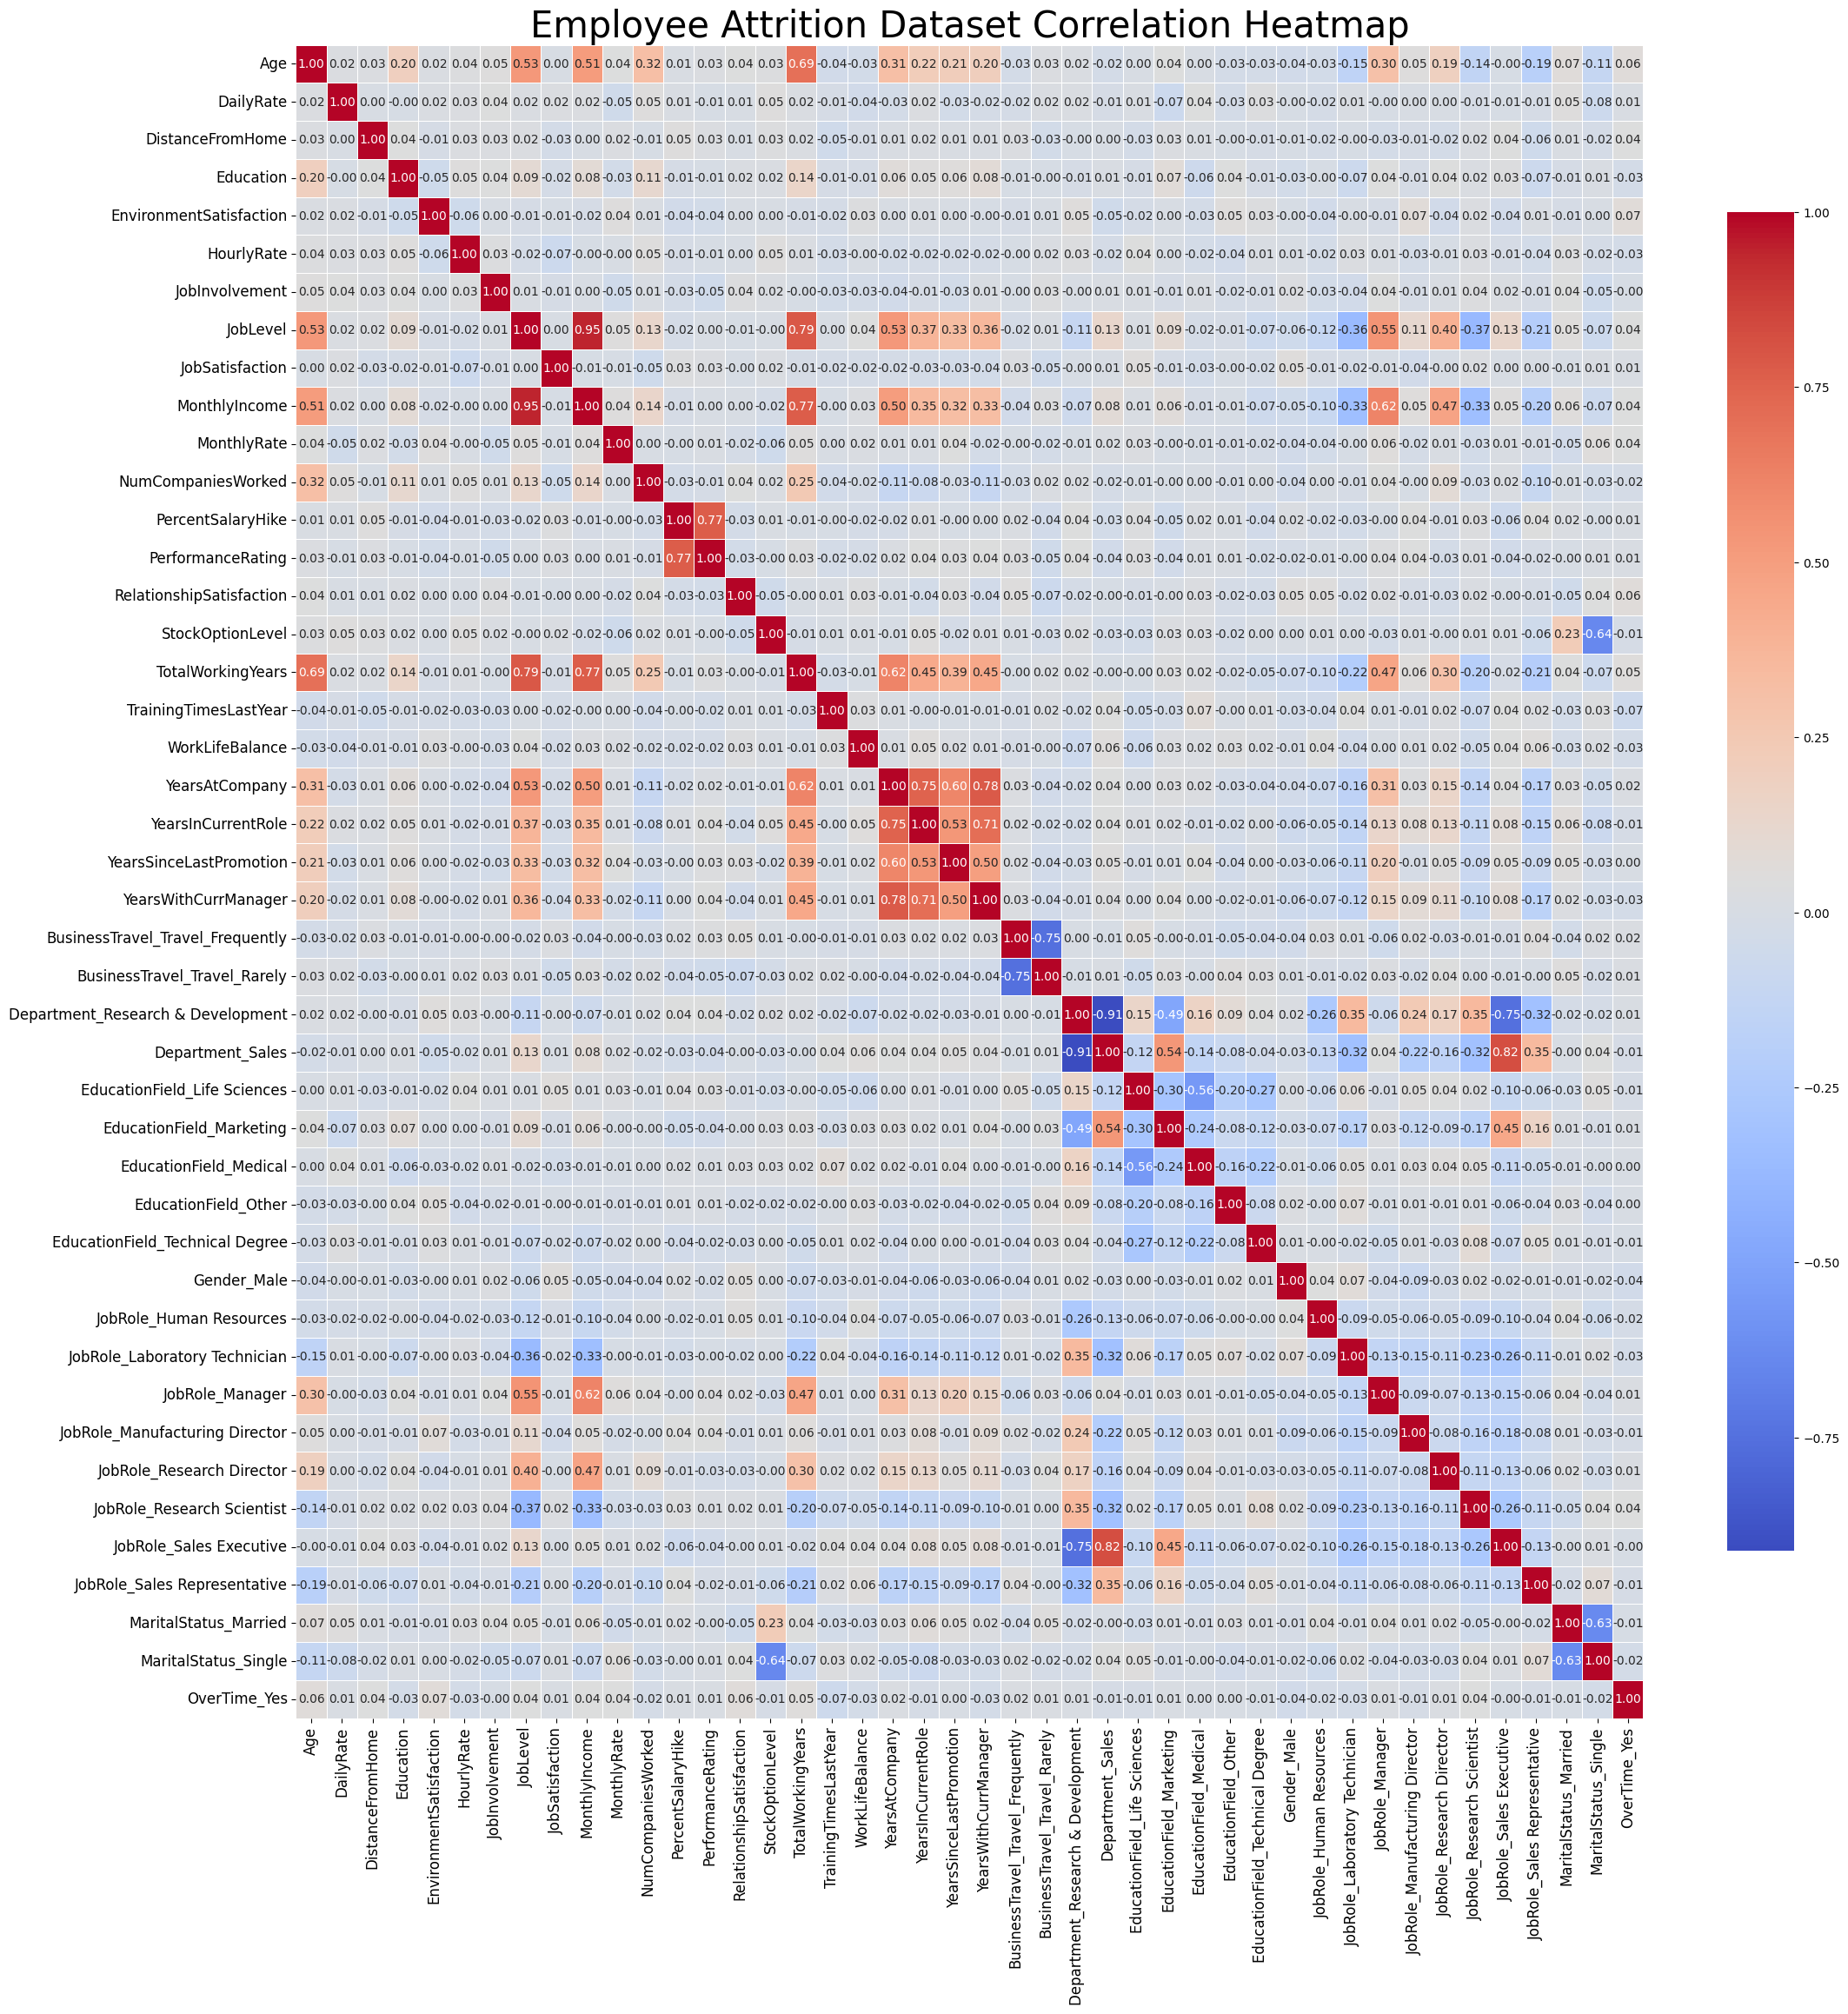

In [357]:
plt.figure(figsize=(25, 25))

sns.heatmap(
    x_train.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f", linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12, rotation=0)
plt.title("Employee Attrition Dataset Correlation Heatmap", fontsize=30)
plt.show()

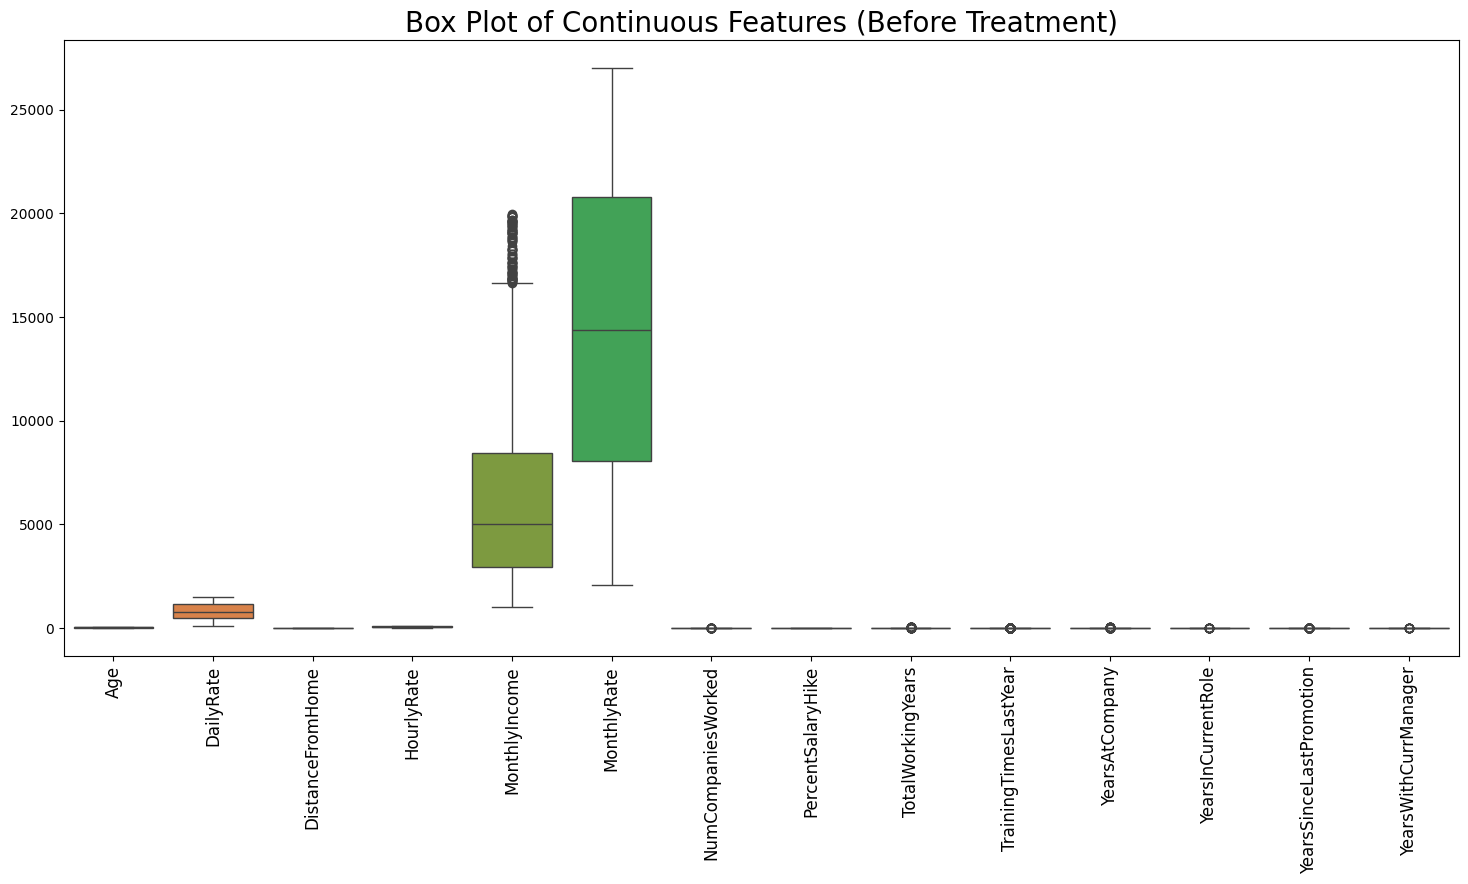

In [358]:
# Box Plot

#Outlier logic below is limited to the numeric columns where "outlier" is a meaningful concept (income, tenure, distance, etc.)

continuous_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate',
    'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

plt.figure(figsize=(18, 8))
sns.boxplot(data=x_train[continuous_cols])
plt.xticks(fontsize=12, rotation=90)
plt.title("Box Plot of Continuous Features (Before Treatment)", fontsize=20)
plt.show()


In [359]:
Q1 = x_train[continuous_cols].quantile(0.25)
Q3 = x_train[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x_train[continuous_cols] = x_train[continuous_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)
x_test[continuous_cols] = x_test[continuous_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

print("x_train shape (no rows lost):", x_train.shape)
print("y_train shape (still matches):", y_train.shape)

x_train shape (no rows lost): (1176, 44)
y_train shape (still matches): (1176,)


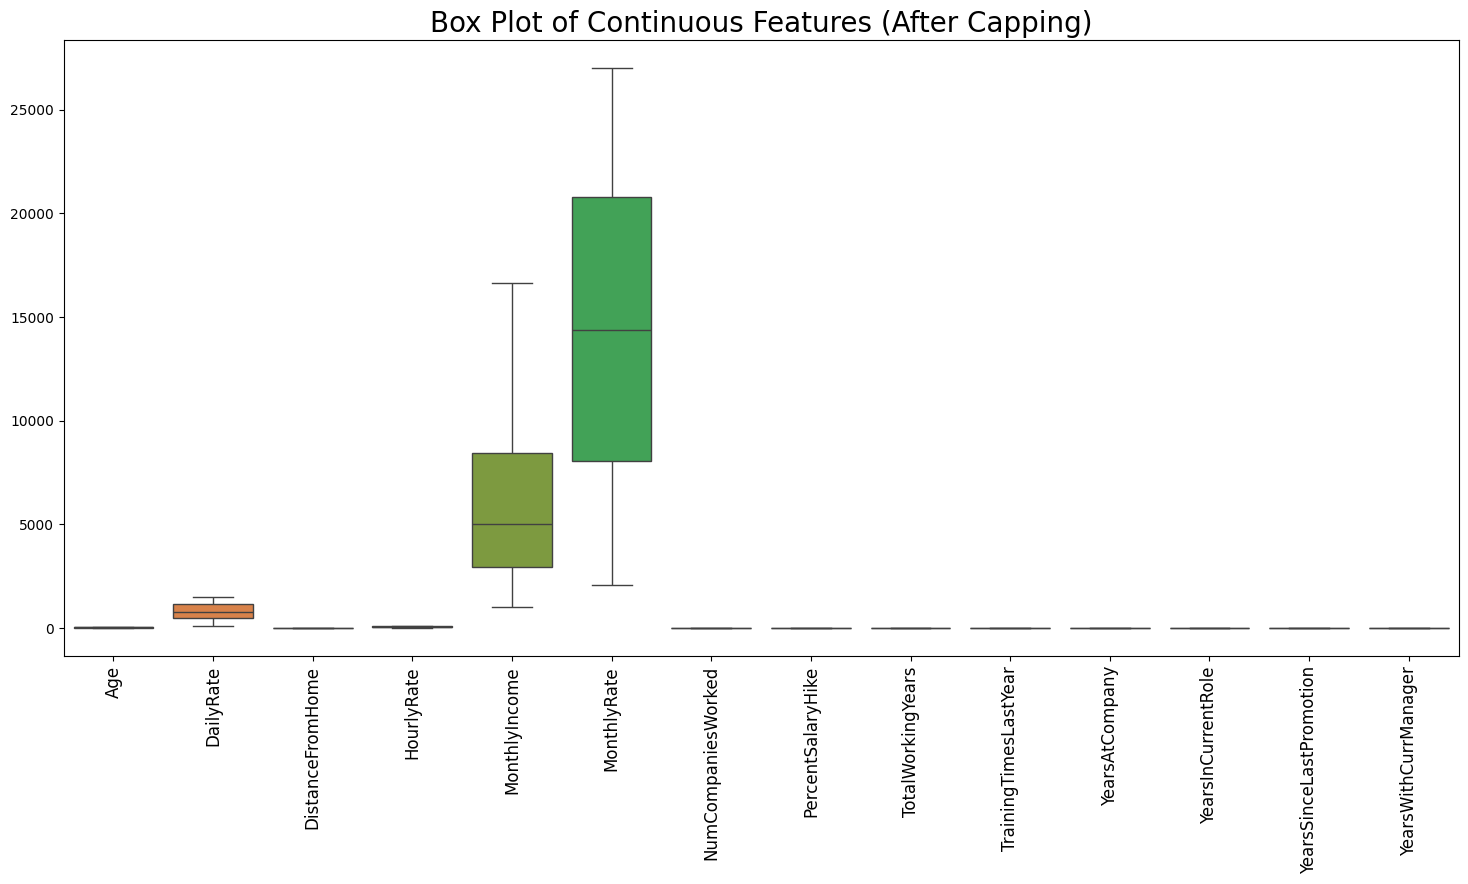

In [360]:
# Box Plot After Outliner Removal
plt.figure(figsize=(18, 8))

sns.boxplot(data=x_train[continuous_cols])
plt.xticks(fontsize=12, rotation=90)
plt.title("Box Plot of Continuous Features (After Capping)", fontsize=20)
plt.show()

In [361]:
# Performing Scaling using Standardization
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

x_train_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,1.090194,1.049455,-0.899915,1.064209,-0.658710,-0.908436,1.795282,1.762189,-0.647997,2.200248,...,-0.472996,3.628867,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,-0.921443,-0.681548,-0.637729
1,-1.634828,-0.523449,-0.899915,-1.855332,0.260202,1.694111,0.373564,-0.986265,1.153526,-0.897869,...,2.114182,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,1.085255,-0.681548,-0.637729
2,0.981193,-0.992080,-0.777610,-1.855332,-1.577622,-0.662913,0.373564,1.762189,0.252765,2.351652,...,-0.472996,3.628867,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,1.085255,-0.681548,-0.637729
3,-1.307825,-0.453653,0.445433,-1.855332,-0.658710,-1.252169,0.373564,-0.986265,0.252765,-0.996233,...,-0.472996,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,4.312772,1.085255,-0.681548,-0.637729
4,0.654191,0.491086,-0.043784,2.037390,1.179114,0.319180,0.373564,-0.070114,0.252765,-0.170852,...,2.114182,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,-0.921443,-0.681548,1.568064


 Below, PCA is shown as an exploratory visualization only, with an explained-variance plot to show how many components would actually be needed to preserve most of the information.

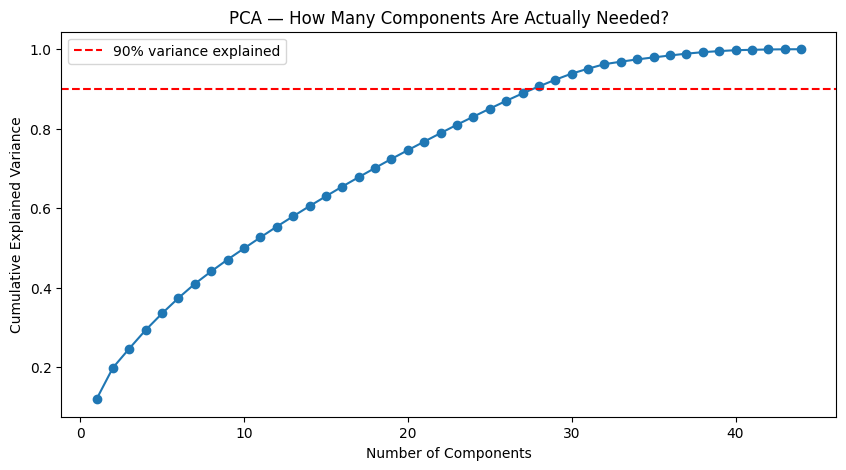

Components needed for 90% variance: 28 (original notebook used 5, which explains only 33.5% of the variance)


In [362]:
pca_full = PCA().fit(x_train_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance explained')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — How Many Components Are Actually Needed?")
plt.legend()
plt.show()

n_needed = np.argmax(explained >= 0.90) + 1
print(f"Components needed for 90% variance: {n_needed} (original notebook used 5, "
      f"which explains only {explained[4]*100:.1f}% of the variance)")

In [363]:
# Apply PCA to reduce no. of Features
from sklearn.decomposition import PCA
pca=PCA(n_components=n_needed)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)
x_train_pca=pd.DataFrame(x_train_pca)
x_test_pca=pd.DataFrame(x_test_pca)

print(pca.n_components_)
print(x_train_pca.shape)
print(x_test_pca.shape)


28
(1176, 28)
(294, 28)


In [364]:
print("x_train_scaled:", x_train_scaled.shape)
print("x_train_pca:", x_train_pca.shape)
print("y_train:", y_train.shape)

x_train_scaled: (1176, 44)
x_train_pca: (1176, 28)
y_train: (1176,)


In [365]:
x_train_pca

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,3.328760,0.782182,-3.703241,1.429055,1.252064,0.793917,0.890649,-0.054996,-0.314959,0.475703,...,-0.166004,-0.959497,1.182239,1.297516,1.115930,-0.150470,-0.572228,-1.113249,1.786253,-0.580379
1,-3.109197,-0.754360,-0.663195,-1.414771,-1.406112,-0.233930,0.556431,-1.367504,-0.581021,0.720072,...,-1.868266,0.563642,-0.503815,-0.277717,-0.517237,2.249740,-0.970120,-0.199997,-1.139805,-0.988538
2,4.960192,2.015967,-1.180738,-0.182372,-0.678271,-0.133458,-0.131564,-1.340260,-0.440091,1.985746,...,-0.672098,1.058406,-0.744247,-0.318953,-0.374116,0.323005,-0.327970,-1.675907,-0.338629,-0.029812
3,-1.668255,2.397634,0.371548,-0.833247,-1.350074,-0.681373,-1.090718,-2.073250,-1.604607,0.945692,...,0.115131,-1.239535,-1.531301,0.647426,1.207867,0.536376,2.104819,-1.539713,-0.526299,1.566312
4,0.395878,-1.530476,1.154642,-0.696661,-0.104958,2.126652,-1.943379,0.217450,1.311854,-0.729583,...,0.474857,-1.152370,-0.521034,0.120400,1.077708,0.346525,-0.231130,2.130570,1.748564,0.202863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,-2.598201,2.253159,0.600373,0.032030,2.398135,-2.178625,1.553907,-1.139144,-1.563853,0.345208,...,0.300193,-1.360999,-1.257508,-0.730215,0.944694,1.148403,0.792624,1.997217,0.321354,1.585200
1172,0.849369,2.243067,0.267718,-0.063678,-0.516563,-0.056740,1.199993,-0.473239,0.423082,-0.424390,...,0.575709,0.107321,0.943744,1.524071,-0.424241,0.020152,0.170529,-2.090882,0.703523,-0.219004
1173,-2.782084,-1.005256,-0.168574,-1.317348,-0.665883,-0.280290,1.903007,-2.442818,1.706509,0.013302,...,-0.211517,1.001639,-0.948731,-1.436697,-2.157604,-1.524567,-0.210876,-0.180996,-0.352548,0.144764
1174,-1.291515,-1.460471,-1.855130,0.041685,2.192827,-2.264460,-0.284271,1.626522,-1.714220,-1.220061,...,1.543431,-0.932871,0.964481,0.144372,-1.613829,1.347919,0.147490,-0.368940,-0.467397,-0.125043


Logistic Regression to penalize mistakes on the minority ("Yes") class more heavily, so it stops being tempted to just predict "No" for everyone.

In [366]:
# Training the Model - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42, class_weight='balanced'
)

# Train the model
model.fit(x_train_pca, y_train)

# Make predictions
y_pred = model.predict(x_test_pca)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7687074829931972

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294


Confusion Matrix:
[[194  53]
 [ 15  32]]


Don't rely on a single train/test split. 5-fold stratified cross-validation on the training set gives a more reliable estimate of how the model performs, using ROC-AUC (a better metric than accuracy for imbalanced classes).

In [367]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("Cross-validated ROC-AUC scores:", cv_scores)
print(f"Mean ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Cross-validated ROC-AUC scores: [0.81353004 0.79535132 0.84464333 0.87176062 0.81779321]
Mean ROC-AUC: 0.829 (+/- 0.027)


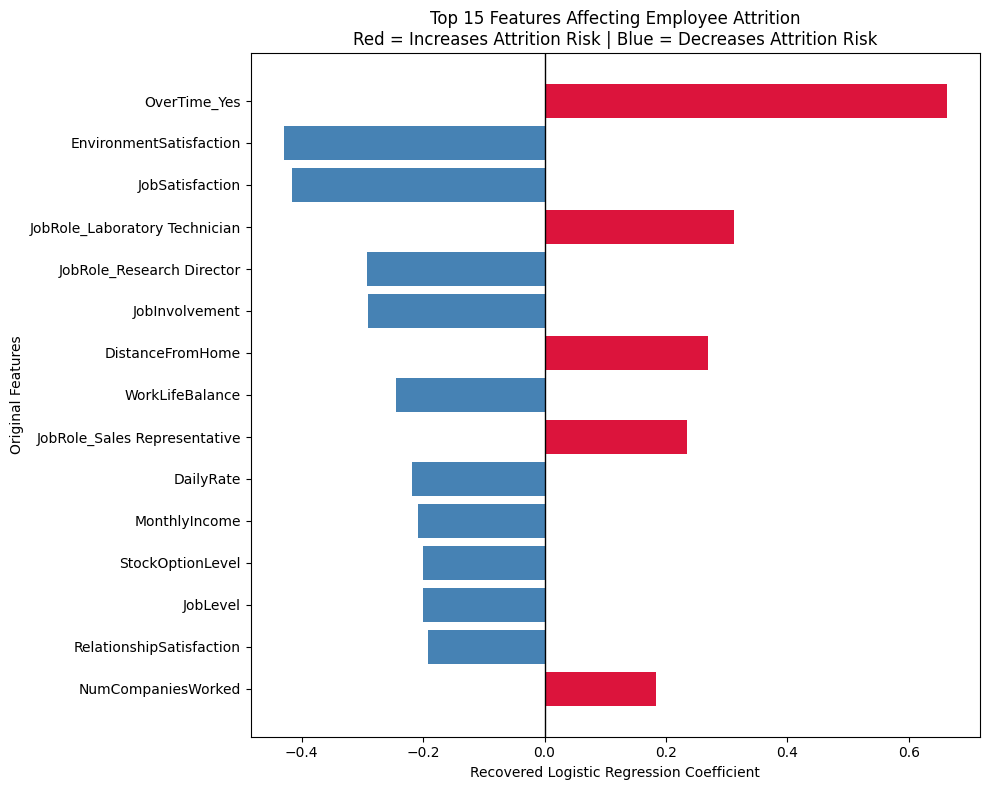

In [372]:
# Convert PCA-space coefficients back to original feature space
original_feature_coefficients = np.dot(
    model.coef_[0],
    pca.components_
)

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Coefficient': original_feature_coefficients,
    'Absolute_Importance': np.abs(original_feature_coefficients)
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Absolute_Importance',
    ascending=False
)

# Select top 15 most important features
top_features = feature_importance.head(15)

# Assign colors based on coefficient direction
colors = [
    'crimson' if coefficient > 0 else 'steelblue'
    for coefficient in top_features['Coefficient']
]

# Create horizontal bar chart
plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient'],
    color=colors
)

# Add a vertical line at zero
plt.axvline(
    x=0,
    color='black',
    linewidth=1
)

# Labels and title
plt.xlabel("Recovered Logistic Regression Coefficient")
plt.ylabel("Original Features")

plt.title(
    "Top 15 Features Affecting Employee Attrition\n"
    "Red = Increases Attrition Risk | Blue = Decreases Attrition Risk"
)

# Show most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()